In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [6]:
data = {
    "Name": ["New York", "São Paulo", "Tokyo", "Lagos", "Sydney"],
    "Population": [8419600, 12325232, 13929286, 1500000, 5312163],
    "Latitude": [40.7128, -23.5505, 35.6895, 6.5244, -33.8688],
    "Longitude": [-74.0060, -46.6333, 139.6917, 3.3792, 151.2093]
}

In [7]:
gdf = gpd.GeoDataFrame(
    data, 
    geometry = gpd.points_from_xy(
        data['Longitude'],
        data['Latitude']
    )
)

In [8]:
gdf

,Name,Population,Latitude,Longitude,geometry
0,New York,8419600,40.7128,-74.0060,POINT (-74.006 40.7128)
1,São Paulo,12325232,-23.5505,-46.6333,POINT (-46.6333 -23.5505)
2,Tokyo,13929286,35.6895,139.6917,POINT (139.6917 35.6895)
3,Lagos,1500000,6.5244,3.3792,POINT (3.3792 6.5244)
4,Sydney,5312163,-33.8688,151.2093,POINT (151.2093 -33.8688)


<Axes: >

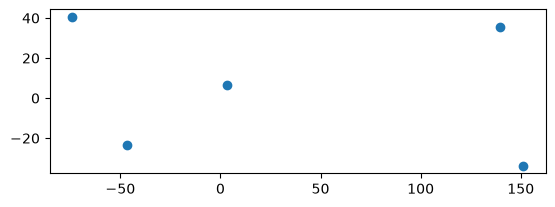

In [9]:
gdf.plot()

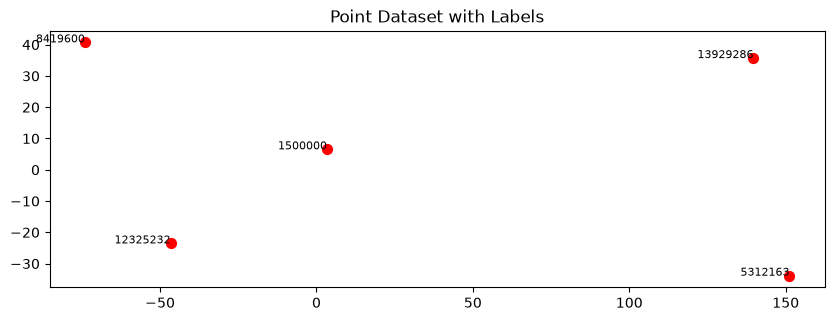

In [10]:
fig, ax = plt.subplots(figsize=(10,10))
gdf.plot(ax = ax, color = 'red', markersize = 50)

for x, y, label in zip (gdf.geometry.x, gdf.geometry.y, gdf['Population']):
    ax.text(x, y, label, fontsize = 8, color = 'black', ha = 'right')

plt.title("Point Dataset with Labels")
plt.show()

In [11]:
#configurando o sistema de projeção das coordenadas

gdf = gdf.set_crs(4326)

In [12]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [13]:
gdf.explore()

In [14]:
import leafmap

In [15]:
#tem mais opções para trabalhar com os mapas

m = leafmap.Map(center= [0,0], zoom = 2)

m

Map(center=[0, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text'…

In [ ]:
#é possível modificar o mapa com código

m.add_gdf(gdf, layer_name='Points')